# Tree Models — M3 (Random Forest) and M4 (XGBoost)

Fits two tree-based models triggered because Ridge regression failed to reliably beat B1 (5.45h RMSE).

| ID | Model | Features |
|----|-------|----------|
| M3 | Random Forest | `length_tier_ord` + complexity flags + video_type dummies (all features combined) |
| M4 | XGBoost | Same features |

Hyperparameters tuned via `GridSearchCV` + `TimeSeriesSplit` on the training set (Layer 1 CV).
Winner selected by mean rolling CV RMSE across 3 folds (Layer 2 CV).
**Must beat B1 RMSE of 5.45h. Reference: M2-raw (honest Ridge) = 5.49h.**

In [1]:
import duckdb
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor
import mlflow
import mlflow.sklearn

sys.path.append('..')
from src.constants import LENGTH_TIER_MAP, LENGTH_TIER_ORDER, LENGTH_TIER_ORDINAL

c:\Machine Learning Projects\YouTube Workload\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Machine Learning Projects\YouTube Workload\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
con = duckdb.connect('../data/workload.duckdb')
videos = con.execute('SELECT * FROM dim_videos_ml').df()
con.close()

videos_complete = videos[videos['is_complete'] == 1].reset_index(drop=True)
print(f"Total: {len(videos)} | Complete: {len(videos_complete)} | Excluded: {len(videos) - len(videos_complete)}")

Total: 126 | Complete: 98 | Excluded: 28


## Setup — Split, Feature Engineering, and Helpers

In [3]:
N_TEST = 25

MODEL_COLS = [
    'expected_length_mins',
    'complexity_new',
    'complexity_media_depth',
    'complexity_delivery_style',
]

df_split = (
    videos_complete[
        ['date_first', 'hours_creation', 'media_title', 'video_type', 'media_type']
        + MODEL_COLS
    ]
    .dropna(subset=['hours_creation'])
    .sort_values('date_first')
    .reset_index(drop=True)
)

n_total    = len(df_split)
cutoff_idx = n_total - N_TEST

train_df = df_split.iloc[:cutoff_idx].copy()
test_df  = df_split.iloc[cutoff_idx:].copy()

print(f"Train: {len(train_df)}  ({train_df['date_first'].min().date()} -> {train_df['date_first'].max().date()})")
print(f"Test:  {len(test_df)}   ({test_df['date_first'].min().date()} -> {test_df['date_first'].max().date()})")

Train: 73  (2023-02-13 -> 2025-01-20)
Test:  25   (2025-02-06 -> 2026-01-20)


In [4]:
def add_features(df):
    df = df.copy()
    df['length_tier']     = df['expected_length_mins'].astype('Int64').map(LENGTH_TIER_MAP)
    df['length_tier_ord'] = df['length_tier'].map(LENGTH_TIER_ORDINAL)
    # video_type dummies — Review dropped as reference level (largest group)
    vtype_dummies = pd.get_dummies(df['video_type'], prefix='vtype').astype(int)
    vtype_dummies = vtype_dummies.drop(columns=['vtype_Review'], errors='ignore')
    df = pd.concat([df, vtype_dummies], axis=1)
    return df

train_df = add_features(train_df)
test_df  = add_features(test_df)

# Align dummies — fill any vtype_ column present in train but absent in test with 0
vtype_cols = [c for c in train_df.columns if c.startswith('vtype_')]
for col in vtype_cols:
    if col not in test_df.columns:
        test_df[col] = 0

print("Feature engineering complete.")
print(f"video_type dummies: {vtype_cols}")

Feature engineering complete.
video_type dummies: ['vtype_Playthrough', 'vtype_Rankings']


In [5]:
# Combined feature set — trees can handle all features together without the
# collinearity concerns that affect linear models
ALL_FEATURES = [
    'length_tier_ord',
    'complexity_new',
    'complexity_media_depth',
    'complexity_delivery_style',
] + vtype_cols

# Flags-only feature set — no video_type dummies (used for M3b)
FLAGS_FEATURES = [
    'length_tier_ord',
    'complexity_new',
    'complexity_media_depth',
    'complexity_delivery_style',
]

# Baselines for reference
B1_RMSE   = 5.45   # success criterion (B1: mean by length tier)
M1R_RMSE  = 4.68   # M1-raw Ridge benchmark (linear winner — flags + length, raw target)

# Colour palette shared across diagnostic plots
tier_colors = {'Short': '#4C72B0', 'Average': '#DD8452', 'Long': '#55A868'}

def rmse(actual, predicted):
    return np.sqrt(np.mean((predicted - actual) ** 2))

print(f"ALL_FEATURES ({len(ALL_FEATURES)}):   {ALL_FEATURES}")
print(f"FLAGS_FEATURES ({len(FLAGS_FEATURES)}): {FLAGS_FEATURES}")

ALL_FEATURES (6):   ['length_tier_ord', 'complexity_new', 'complexity_media_depth', 'complexity_delivery_style', 'vtype_Playthrough', 'vtype_Rankings']
FLAGS_FEATURES (4): ['length_tier_ord', 'complexity_new', 'complexity_media_depth', 'complexity_delivery_style']


In [6]:
from pathlib import Path

# Pin MLflow tracking to the project root so runs are always written
# to <project_root>/mlruns/ regardless of where the notebook is executed from.
MLFLOW_DIR = Path('../mlruns').resolve()
mlflow.set_tracking_uri(f'file:///{MLFLOW_DIR}')
mlflow.set_experiment('yt-hours-trees')
print(f'MLflow tracking URI: {mlflow.get_tracking_uri()}')


c:\Machine Learning Projects\YouTube Workload\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/11 09:05:14 INFO mlflow.tracking.fluent: Experiment with name 'yt-hours-trees' does not exist. Creating a new experiment.


MLflow tracking URI: file:///C:\Machine Learning Projects\YouTube Workload\mlruns


## Layer 2 — Rolling CV (Model Selection)

Same 3-fold expanding window structure as the linear notebook.

For each fold, hyperparameters are tuned via `GridSearchCV` + `TimeSeriesSplit` on that fold's training window (Layer 1), then RMSE is computed on the fold's test window. Mean RMSE across folds determines the winning model.

In [7]:
def rolling_cv_tree(train_df, features, estimator, param_grid, n_splits=3, label=''):
    """
    Layer 2 rolling CV for one tree model.

    For each fold:
      - Layer 1: GridSearchCV tunes hyperparameters on fold's training window
                 using TimeSeriesSplit (n_splits=3), scoring=RMSE
      - Predicts on fold's test window
      - Returns per-fold RMSE in original hours scale

    Fold construction (same as linear notebook):
      - start     = int(n * 0.35)          — minimum training window
      - fold_size = (n - start) // n_folds  — equal test windows
    """
    n         = len(train_df)
    n_folds   = 3
    start     = int(n * 0.35)
    fold_size = (n - start) // n_folds

    folds = [
        (start + i * fold_size, start + (i + 1) * fold_size)
        for i in range(n_folds)
    ]

    fold_rmses  = []
    fold_params = []

    for fold_idx, (test_start, test_end) in enumerate(folds):
        fold_train = train_df.iloc[:test_start].dropna(subset=features + ['hours_creation'])
        fold_test  = train_df.iloc[test_start:test_end].dropna(subset=features + ['hours_creation'])

        if len(fold_train) < 10 or len(fold_test) == 0:
            continue

        X_tr = fold_train[features].astype(float).values
        X_te = fold_test[features].astype(float).values
        y_tr = fold_train['hours_creation'].values
        y_te = fold_test['hours_creation'].values

        # Layer 1: tune hyperparameters within fold's training window
        tscv   = TimeSeriesSplit(n_splits=n_splits)
        search = GridSearchCV(
            estimator,
            param_grid,
            cv=tscv,
            scoring='neg_root_mean_squared_error',
            refit=True,
            n_jobs=-1,
        )
        search.fit(X_tr, y_tr)
        fold_params.append(dict(search.best_params_))

        preds     = search.predict(X_te)
        fold_rmse = rmse(y_te, preds)
        fold_rmses.append(fold_rmse)
        print(f"  Fold {fold_idx+1}: train n={len(fold_train)}, test n={len(fold_test)}, "
              f"best params={search.best_params_}, RMSE={fold_rmse:.2f}h")

    mean_rmse = np.mean(fold_rmses)
    print(f"  Mean CV RMSE: {mean_rmse:.2f}h")
    return mean_rmse, fold_rmses, fold_params


print("Rolling CV function defined.")

Rolling CV function defined.


In [8]:
cv_results = {}

# ── M3: Random Forest ─────────────────────────────────────────────────────────
# max_depth: None = fully grown trees (can overfit at small n); small values regularise
# min_samples_leaf: minimum observations in a leaf — key regulariser for small datasets
# n_estimators: more trees = lower variance, diminishing returns past ~200
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [2, 3, 5, None],
    'min_samples_leaf': [2, 4, 6],
}

print("── M3: Random Forest (all 6 features) ───────────────")
cv_results['M3'] = rolling_cv_tree(
    train_df,
    ALL_FEATURES,
    RandomForestRegressor(random_state=42),
    rf_param_grid,
)

# ── M4: XGBoost ───────────────────────────────────────────────────────────────
# n_estimators: number of boosting rounds
# max_depth: tree depth — keep shallow (2-4) to avoid overfitting at small n
# learning_rate: shrinks each tree's contribution; lower = more robust but needs more trees
# subsample: fraction of training rows used per tree — adds randomness, reduces overfitting
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.7, 1.0],
}

print("\n── M4: XGBoost (all 6 features) ─────────────────────")
cv_results['M4'] = rolling_cv_tree(
    train_df,
    ALL_FEATURES,
    XGBRegressor(random_state=42, verbosity=0),
    xgb_param_grid,
)

print("\n" + "=" * 60)
print(f"  {'Model':<8}  {'Mean CV RMSE':>14}  {'vs B1 (5.45h)':>14}")
print(f"  {'-'*8}  {'-'*14}  {'-'*14}")
for name, (mean_rmse, *_) in cv_results.items():
    delta = mean_rmse - B1_RMSE
    flag  = '  BEATS B1' if mean_rmse < B1_RMSE else ''
    print(f"  {name:<8}  {mean_rmse:>13.2f}h  {delta:>+13.2f}h{flag}")
print(f"  {'M1-raw':<8}  {M1R_RMSE:>13.2f}h  {M1R_RMSE - B1_RMSE:>+13.2f}h  (Ridge benchmark)")
print("=" * 60)

── M3: Random Forest (all 6 features) ───────────────
  Fold 1: train n=25, test n=16, best params={'max_depth': 2, 'min_samples_leaf': 4, 'n_estimators': 100}, RMSE=8.89h
  Fold 2: train n=41, test n=16, best params={'max_depth': 2, 'min_samples_leaf': 2, 'n_estimators': 200}, RMSE=9.78h
  Fold 3: train n=57, test n=16, best params={'max_depth': 3, 'min_samples_leaf': 2, 'n_estimators': 200}, RMSE=10.24h
  Mean CV RMSE: 9.64h

── M4: XGBoost (all 6 features) ─────────────────────
  Fold 1: train n=25, test n=16, best params={'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 50, 'subsample': 1.0}, RMSE=8.20h
  Fold 2: train n=41, test n=16, best params={'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50, 'subsample': 0.7}, RMSE=9.96h
  Fold 3: train n=57, test n=16, best params={'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.7}, RMSE=11.82h
  Mean CV RMSE: 9.99h

  Model       Mean CV RMSE   vs B1 (5.45h)
  --------  --------------  --------------

## M3b — Random Forest, Flags Only (No Video_Type Dummies)

After evaluating M3 (6 features), the `video_type` dummies were found to have data integrity problems relative to the train/test split:

- **Scene Breakdowns** appear only in the test set — `vtype_Scene_Breakdown` is all zeros in training, so the tree could not have learned a valid split on it. Any scene breakdown in the test set is predicted via `length_tier_ord` and flags alone.
- **Playthroughs** are heavily represented in training but only once in the test set — effectively untestable.
- In M3's feature importance, the vtype dummies contributed very little (Playthrough: 0.013, Rankings: 0.027). `length_tier_ord` dominated at 0.68.

M3b drops the dummies entirely and uses only `FLAGS_FEATURES` (4 features, identical to M1-raw's feature set). This tests whether the dummies were adding signal or noise, and removes the extrapolation risk for unseen video types.

Same `rf_param_grid`, same `rolling_cv_tree()` function, same GridSearchCV + TimeSeriesSplit structure.

In [9]:
print("── M3b: Random Forest (flags only, no dummies) ───────")
cv_results['M3b'] = rolling_cv_tree(
    train_df,
    FLAGS_FEATURES,
    RandomForestRegressor(random_state=42),
    rf_param_grid,
)

print("\n" + "=" * 65)
print(f"  {'Model':<8}  {'Features':<10}  {'Mean CV RMSE':>14}  {'vs B1':>10}  {'vs M1-raw':>10}")
print(f"  {'-'*8}  {'-'*10}  {'-'*14}  {'-'*10}  {'-'*10}")
for name, (mean_rmse, *_) in cv_results.items():
    feats = 'flags+dummies' if name in ('M3', 'M4') else 'flags only'
    b1_delta   = mean_rmse - B1_RMSE
    m1r_delta  = mean_rmse - M1R_RMSE
    flag = '  BEATS B1' if mean_rmse < B1_RMSE else ''
    print(f"  {name:<8}  {feats:<13}  {mean_rmse:>13.2f}h  {b1_delta:>+9.2f}h  {m1r_delta:>+9.2f}h{flag}")
print(f"  {'M1-raw':<8}  {'flags only':<13}  {M1R_RMSE:>13.2f}h  {M1R_RMSE-B1_RMSE:>+9.2f}h  {'(Ridge benchmark)':>10}")
print("=" * 65)

── M3b: Random Forest (flags only, no dummies) ───────
  Fold 1: train n=25, test n=16, best params={'max_depth': 2, 'min_samples_leaf': 4, 'n_estimators': 100}, RMSE=8.89h
  Fold 2: train n=41, test n=16, best params={'max_depth': 2, 'min_samples_leaf': 2, 'n_estimators': 200}, RMSE=9.85h
  Fold 3: train n=57, test n=16, best params={'max_depth': 3, 'min_samples_leaf': 2, 'n_estimators': 200}, RMSE=9.43h
  Mean CV RMSE: 9.39h

  Model     Features      Mean CV RMSE       vs B1   vs M1-raw
  --------  ----------  --------------  ----------  ----------
  M3        flags+dummies           9.64h      +4.19h      +4.96h
  M4        flags+dummies           9.99h      +4.54h      +5.31h
  M3b       flags only              9.39h      +3.94h      +4.71h
  M1-raw    flags only              4.68h      -0.77h  (Ridge benchmark)


In [10]:
# Log all 3 CV variants to MLflow — one run per variant
feature_map = {
    'M3':  ALL_FEATURES,
    'M4':  ALL_FEATURES,
    'M3b': FLAGS_FEATURES,
}

for variant_name, (mean_rmse, fold_rmses, fold_params) in cv_results.items():
    with mlflow.start_run(run_name=f'cv_{variant_name}'):
        mlflow.log_param('variant',      variant_name)
        mlflow.log_param('features',     feature_map[variant_name])
        mlflow.log_param('n_splits',     3)
        mlflow.log_param('train_n',      len(train_df))
        mlflow.log_param('b1_rmse',      B1_RMSE)
        mlflow.log_param('m1_raw_rmse',  M1R_RMSE)
        mlflow.log_param('cv_mean_rmse', round(mean_rmse, 4))
        mlflow.log_param('beats_b1',     int(mean_rmse < B1_RMSE))
        mlflow.log_param('beats_m1_raw', int(mean_rmse < M1R_RMSE))
        # Per-fold best hyperparameters — detect if tuning is stable across folds
        for i, params in enumerate(fold_params, 1):
            for k, v in params.items():
                mlflow.log_param(f'fold_{i}_{k}', v)
        # Fold RMSE trend with step= creates a line graph in MLflow UI
        for i, fold_rmse in enumerate(fold_rmses, 1):
            mlflow.log_metric('cv_fold_rmse', round(fold_rmse, 4), step=i)

print('CV runs logged to MLflow. Run mlflow ui from project root to view.')


CV runs logged to MLflow. Run mlflow ui from project root to view.


## Holdout Diagnostics

| Plot | What to look for |
|------|-----------------|
| **Actual vs Predicted** | Points close to the diagonal = good. Trees can produce flat prediction bands (all predictions cluster around a few leaf values) — visible as horizontal stripes. |
| **Residuals over Time** | Is the distribution shift less severe than Ridge? Trees can sometimes adapt better to non-linearity. |
| **CV Fold RMSE** | Are bars stable across folds (like M2-raw) or rising (like M1-raw)? Stability = trustworthy holdout. |
| **Feature Importance** | Which features the model relied on most. `length_tier_ord` should dominate; if a dummy dominates on 16 training examples it may be a noise fit. |

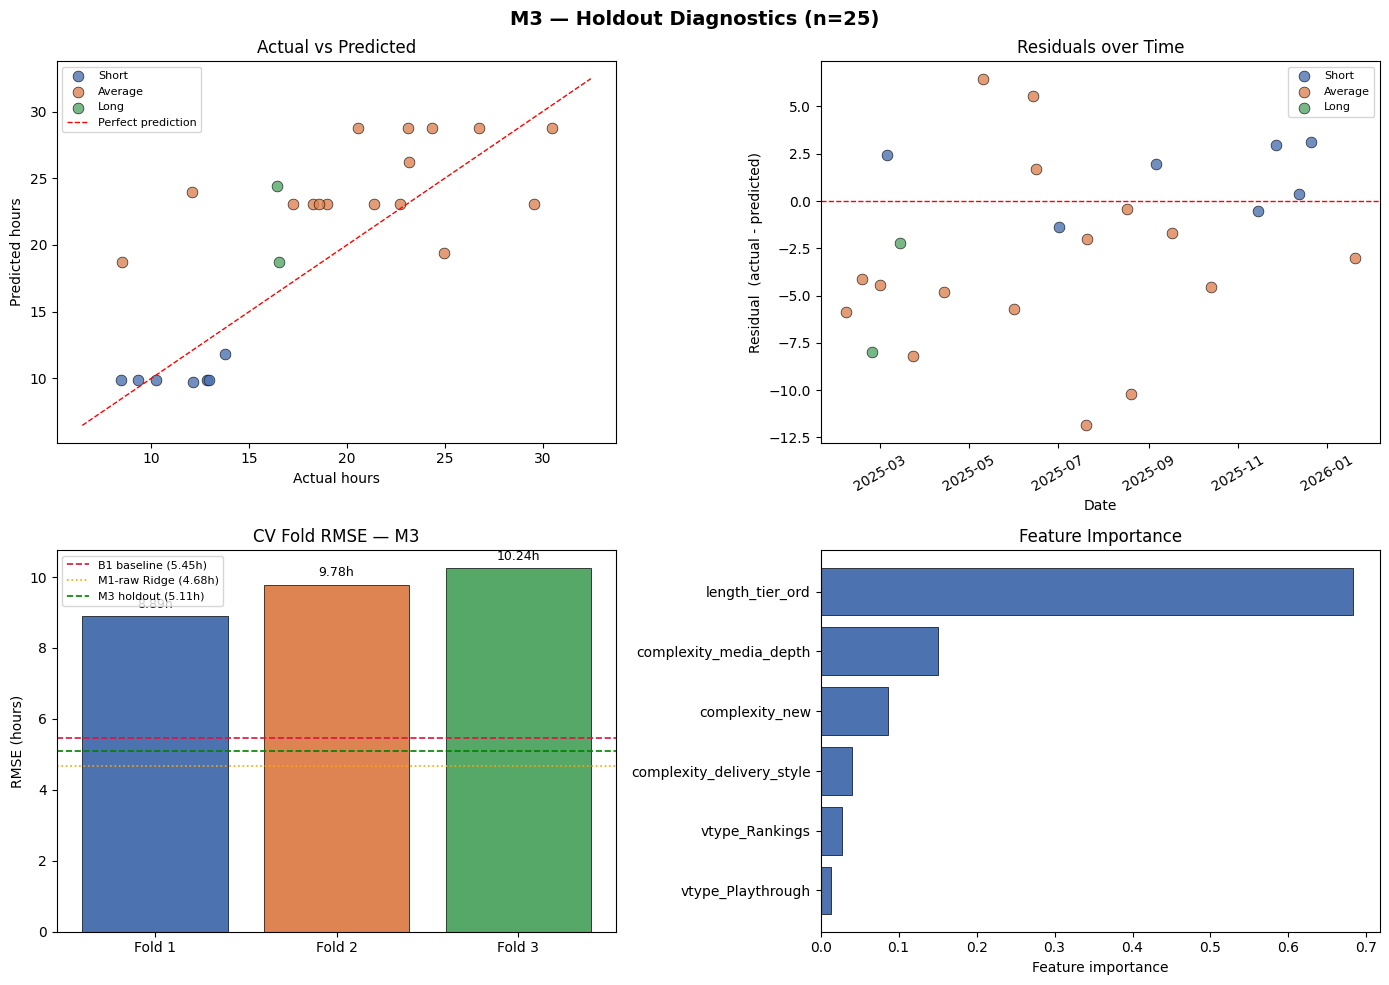


Residual summary (M3 holdout):
  Mean residual:    -2.18h
  Std of residuals: 4.62h

Mean residual by length tier:
  Short     n=7  mean residual=+1.28h
  Average   n=16  mean residual=-3.33h
  Long      n=2  mean residual=-5.13h


In [20]:
residuals = y_test - final_preds
tiers     = test_clean['length_tier'].values
dates     = test_clean['date_first'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{WINNER_NAME} — Holdout Diagnostics (n=25)', fontsize=14, fontweight='bold')

# ── 1. Actual vs Predicted ────────────────────────────────────────────────────
ax = axes[0, 0]
for tier in LENGTH_TIER_ORDER:
    mask = tiers == tier
    ax.scatter(y_test[mask], final_preds[mask],
               color=tier_colors[tier], label=tier,
               alpha=0.8, edgecolors='k', linewidths=0.5, s=60)
lim = [min(y_test.min(), final_preds.min()) - 2,
       max(y_test.max(), final_preds.max()) + 2]
ax.plot(lim, lim, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual hours')
ax.set_ylabel('Predicted hours')
ax.set_title('Actual vs Predicted')
ax.legend(fontsize=8)

# ── 2. Residuals over Time ────────────────────────────────────────────────────
ax = axes[0, 1]
for tier in LENGTH_TIER_ORDER:
    mask = tiers == tier
    ax.scatter(dates[mask], residuals[mask],
               color=tier_colors[tier], label=tier,
               alpha=0.8, edgecolors='k', linewidths=0.5, s=60)
ax.axhline(0, color='r', linestyle='--', linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Residual  (actual - predicted)')
ax.set_title('Residuals over Time')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=8)

# ── 3. CV Fold RMSE vs Baselines ─────────────────────────────────────────────
ax = axes[1, 0]
winner_fold_rmses = cv_results[WINNER_NAME][1]
fold_labels = [f'Fold {i+1}' for i in range(len(winner_fold_rmses))]
bars = ax.bar(fold_labels, winner_fold_rmses,
              color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='k', linewidth=0.5)
ax.axhline(B1_RMSE,    color='crimson', linestyle='--', linewidth=1.2,
           label=f'B1 baseline ({B1_RMSE}h)')
ax.axhline(M1R_RMSE,   color='orange',  linestyle=':',  linewidth=1.2,
           label=f'M1-raw Ridge ({M1R_RMSE}h)')
ax.axhline(final_rmse, color='green',   linestyle='--', linewidth=1.2,
           label=f'{WINNER_NAME} holdout ({final_rmse:.2f}h)')
for bar, val in zip(bars, winner_fold_rmses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f'{val:.2f}h', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('RMSE (hours)')
ax.set_title(f'CV Fold RMSE — {WINNER_NAME}')
ax.legend(fontsize=8)

# ── 4. Feature Importance ─────────────────────────────────────────────────────
ax = axes[1, 1]
importances = final_search.best_estimator_.feature_importances_
feat_imp = sorted(zip(WINNER_FEATURES, importances), key=lambda x: x[1])
feats, imps = zip(*feat_imp)
ax.barh(feats, imps, color='#4C72B0', edgecolor='k', linewidth=0.5)
ax.set_xlabel('Feature importance')
ax.set_title('Feature Importance')

plt.tight_layout()
plt.show()

print(f"\nResidual summary ({WINNER_NAME} holdout):")
print(f"  Mean residual:    {residuals.mean():+.2f}h")
print(f"  Std of residuals: {residuals.std():.2f}h")
print(f"\nMean residual by length tier:")
for tier in LENGTH_TIER_ORDER:
    mask = tiers == tier
    if mask.sum() > 0:
        print(f"  {tier:<8}  n={mask.sum()}  mean residual={residuals[mask].mean():+.2f}h")

## Final Evaluation — Holdout

Retrain the winning model on the full training set with hyperparameters re-tuned via `GridSearchCV` + `TimeSeriesSplit`, then evaluate once on the 25-video holdout.

Note this gets replaced by M3b once i evaluated this model.

In [11]:
# ── Set winner here after reviewing CV results above ─────────────────────────
WINNER_NAME      = 'M3'                                      # <-- 'M3', 'M4', or 'M3b'
WINNER_ESTIMATOR = RandomForestRegressor(random_state=42)    # <-- swap to XGBRegressor if M4 wins
WINNER_PARAMS    = rf_param_grid                             # <-- swap to xgb_param_grid if M4 wins
WINNER_FEATURES  = ALL_FEATURES                              # <-- swap to FLAGS_FEATURES if M3b wins
# ─────────────────────────────────────────────────────────────────────────────

train_clean = train_df.dropna(subset=WINNER_FEATURES + ['hours_creation'])
test_clean  = test_df.dropna(subset=WINNER_FEATURES + ['hours_creation'])

X_train = train_clean[WINNER_FEATURES].astype(float).values
X_test  = test_clean[WINNER_FEATURES].astype(float).values
y_train = train_clean['hours_creation'].values
y_test  = test_clean['hours_creation'].values

tscv         = TimeSeriesSplit(n_splits=3)
final_search = GridSearchCV(
    WINNER_ESTIMATOR,
    WINNER_PARAMS,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    refit=True,
    n_jobs=-1,
)
final_search.fit(X_train, y_train)

final_preds = final_search.predict(X_test)
final_rmse  = rmse(y_test, final_preds)

print(f"Winner: {WINNER_NAME}")
print(f"Best params: {final_search.best_params_}")
print(f"Holdout RMSE:      {final_rmse:.2f}h")
print(f"vs B1   (5.45h):   {final_rmse - B1_RMSE:+.2f}h")
print(f"vs M1-raw (4.68h): {final_rmse - M1R_RMSE:+.2f}h  (Ridge benchmark)")

print(f"\nFeature importances:")
importances = final_search.best_estimator_.feature_importances_
for feat, imp in sorted(zip(WINNER_FEATURES, importances), key=lambda x: -x[1]):
    print(f"  {feat:<35} {imp:.4f}")

Winner: M3
Best params: {'max_depth': 2, 'min_samples_leaf': 2, 'n_estimators': 200}
Holdout RMSE:      5.11h
vs B1   (5.45h):   -0.34h
vs M1-raw (4.68h): +0.43h  (Ridge benchmark)

Feature importances:
  length_tier_ord                     0.6832
  complexity_media_depth              0.1508
  complexity_new                      0.0863
  complexity_delivery_style           0.0399
  vtype_Rankings                      0.0268
  vtype_Playthrough                   0.0129


## Hyperparameter Tuning Diagnostics (M3 — Random Forest)

`GridSearchCV` stores the full results for every parameter combination tried in `final_search.cv_results_`. These plots let us inspect the tuning landscape — not just what the winning config was, but whether the search was well-behaved.

| Plot | What to look for |
|------|-----------------|
| **Mean RMSE heatmap** (`max_depth` × `min_samples_leaf`) | Smooth gradient = well-behaved tuning. If the best cell is isolated with high values surrounding it, the winner may be a noise fit. |
| **Stability heatmap** (same axes, colour = std of RMSE) | High std = inner folds disagreed on that config — the "win" may not hold on new data. Prefer low-std configurations even if mean RMSE is slightly worse. |
| **n_estimators line plot** | Flat lines = diminishing returns from adding trees (stable). Declining lines = more trees still helping. Rising lines = more trees overfitting (rare for RF). |

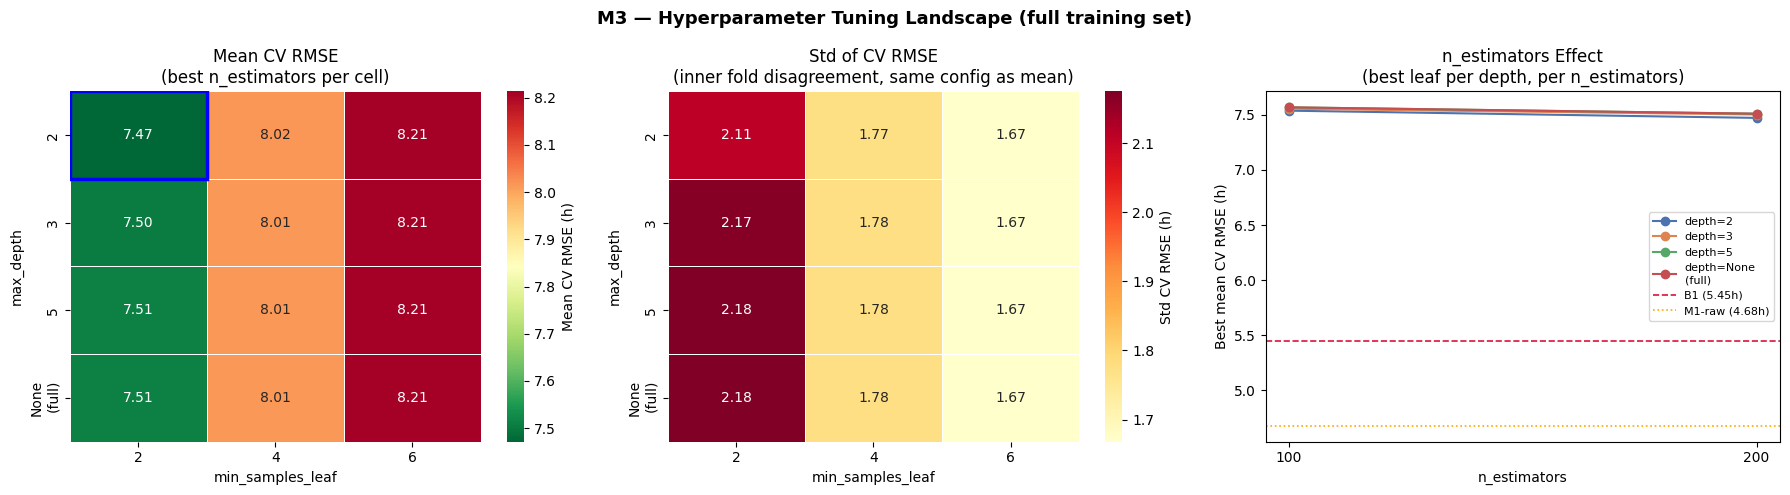


Winning config: {'max_depth': 2, 'min_samples_leaf': 2, 'n_estimators': 200}
Mean CV RMSE at winner: 7.47h
Std  CV RMSE at winner: 2.11h


In [12]:
import seaborn as sns

cv_df = pd.DataFrame(final_search.cv_results_)

# Scores are neg_RMSE — negate to get positive RMSE values
cv_df['mean_rmse'] = -cv_df['mean_test_score']
cv_df['std_rmse']  =  cv_df['std_test_score']

# Readable max_depth label (None → "None (full)")
cv_df['depth_label'] = cv_df['param_max_depth'].apply(
    lambda x: 'None\n(full)' if x is None else str(x)
)
depth_order = ['2', '3', '5', 'None\n(full)']

# For each depth×leaf cell, find the row with the minimum mean RMSE.
# Both heatmaps use the same row — so std shown is the std of the config
# that actually won for that cell, not the config with the lowest std.
best_per_cell = (
    cv_df.loc[
        cv_df.groupby(['depth_label', 'param_min_samples_leaf'])['mean_rmse'].idxmin()
    ]
    .set_index(['depth_label', 'param_min_samples_leaf'])
)

heat_mean = best_per_cell['mean_rmse'].unstack('param_min_samples_leaf').reindex(depth_order)
heat_std  = best_per_cell['std_rmse'].unstack('param_min_samples_leaf').reindex(depth_order)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{WINNER_NAME} — Hyperparameter Tuning Landscape (full training set)',
             fontsize=13, fontweight='bold')

# ── 1. Mean RMSE heatmap ──────────────────────────────────────────────────────
ax = axes[0]
sns.heatmap(
    heat_mean, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn_r',
    linewidths=0.5, cbar_kws={'label': 'Mean CV RMSE (h)'}
)
ax.set_title('Mean CV RMSE\n(best n_estimators per cell)')
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('max_depth')

# Mark winning cell (blue border)
best_row   = cv_df.loc[cv_df['mean_rmse'].idxmin()]
best_depth = best_row['depth_label']
best_leaf  = best_row['param_min_samples_leaf']
if best_depth in depth_order and best_leaf in heat_mean.columns:
    row_idx = depth_order.index(best_depth)
    col_idx = list(heat_mean.columns).index(best_leaf)
    ax.add_patch(plt.Rectangle((col_idx, row_idx), 1, 1, fill=False,
                                edgecolor='blue', lw=2.5))

# ── 2. Std RMSE heatmap (matched to same row as mean) ────────────────────────
ax = axes[1]
sns.heatmap(
    heat_std, ax=ax, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, cbar_kws={'label': 'Std CV RMSE (h)'}
)
ax.set_title('Std of CV RMSE\n(inner fold disagreement, same config as mean)')
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('max_depth')

# ── 3. n_estimators line plot ─────────────────────────────────────────────────
ax = axes[2]
line_colors = {'2': '#4C72B0', '3': '#DD8452', '5': '#55A868', 'None\n(full)': '#C44E52'}

for depth in depth_order:
    subset  = cv_df[cv_df['depth_label'] == depth]
    grouped = subset.groupby('param_n_estimators')['mean_rmse'].min().reset_index()
    ax.plot(grouped['param_n_estimators'], grouped['mean_rmse'],
            marker='o', label=f'depth={depth}', color=line_colors[depth])

ax.axhline(B1_RMSE,  color='crimson', linestyle='--', linewidth=1.2, label=f'B1 ({B1_RMSE}h)')
ax.axhline(M1R_RMSE, color='orange',  linestyle=':',  linewidth=1.2, label=f'M1-raw ({M1R_RMSE}h)')
ax.set_xlabel('n_estimators')
ax.set_ylabel('Best mean CV RMSE (h)')
ax.set_title('n_estimators Effect\n(best leaf per depth, per n_estimators)')
ax.legend(fontsize=8)
ax.set_xticks([100, 200])

fig_heatmap_m3 = fig
plt.tight_layout()
plt.show()

print(f"\nWinning config: {final_search.best_params_}")
print(f"Mean CV RMSE at winner: {best_row['mean_rmse']:.2f}h")
print(f"Std  CV RMSE at winner: {best_row['std_rmse']:.2f}h")

In [13]:
# Log the winning tree model's holdout run to MLflow
with mlflow.start_run(run_name=f'holdout_{WINNER_NAME}'):
    mlflow.log_param('model',        WINNER_NAME)
    mlflow.log_param('features',     WINNER_FEATURES)
    mlflow.log_param('train_n',      len(X_train))
    mlflow.log_param('test_n',       len(X_test))
    mlflow.log_param('b1_rmse',      B1_RMSE)
    mlflow.log_param('m1_raw_rmse',  M1R_RMSE)
    mlflow.log_param('holdout_rmse', round(float(final_rmse), 4))
    mlflow.log_param('beats_b1',     int(final_rmse < B1_RMSE))
    for k, v in final_search.best_params_.items():
        mlflow.log_param(k, v)
    # beats_m1_raw as metric so retrain history shows whether the tree
    # ever crosses the Ridge threshold as training data grows.
    mlflow.log_metric('beats_m1_raw', int(final_rmse < M1R_RMSE))
    for feat, imp in zip(WINNER_FEATURES, final_search.best_estimator_.feature_importances_):
        mlflow.log_metric(f'importance_{feat}', round(float(imp), 4))
    mlflow.log_figure(fig_heatmap_m3, 'tuning_heatmap.png')
    mlflow.sklearn.log_model(final_search.best_estimator_, artifact_path='model')

print(f'Holdout run logged: {WINNER_NAME}, RMSE={final_rmse:.2f}h')


2026/03/11 09:07:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 09:07:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Holdout run logged: M3, RMSE=5.11h


### Dominant Hyperparameter — `min_samples_leaf`

The heatmaps above show that each column (one per `min_samples_leaf` value) is nearly a single colour — RMSE barely changes across rows (`max_depth`). This means `min_samples_leaf` is doing almost all the regularisation work; `max_depth` is secondary once the leaf floor is set.

The bar chart below makes this explicit by collapsing over `max_depth` and `n_estimators`.

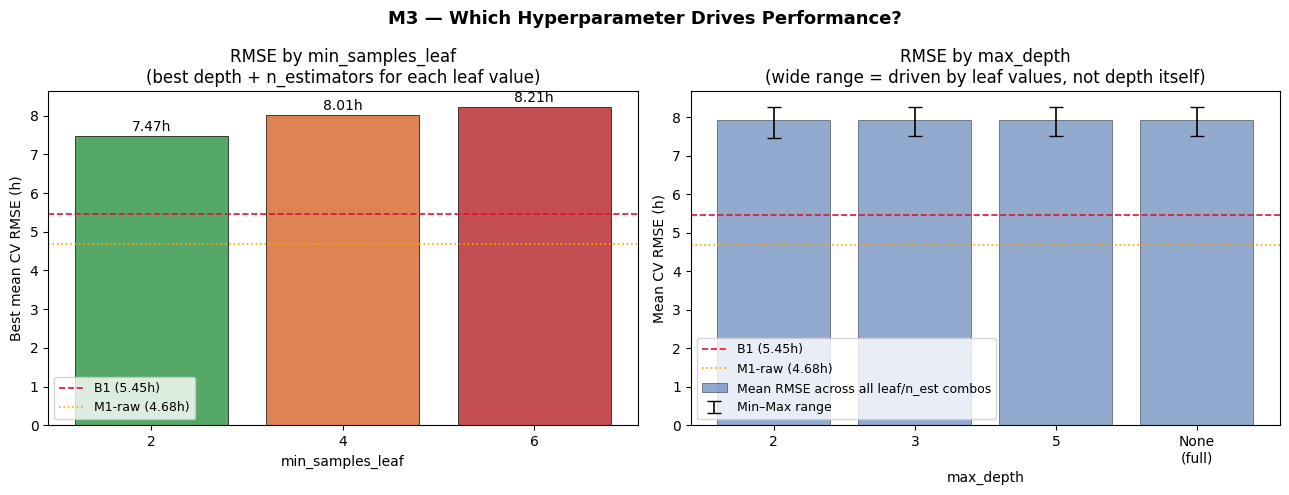

Interpretation:
  min_samples_leaf range: 7.47h – 8.21h  (spread = 0.74h)
  max_depth range:        7.47h – 8.26h  (spread = 0.79h)

  → min_samples_leaf explains most of the variation. max_depth is secondary.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'{WINNER_NAME} — Which Hyperparameter Drives Performance?', fontsize=13, fontweight='bold')

leaf_vals  = sorted(cv_df['param_min_samples_leaf'].unique())
depth_order_local = ['2', '3', '5', 'None\n(full)']

# ── 1. Mean RMSE by min_samples_leaf ─────────────────────────────────────────
ax = axes[0]
leaf_means = cv_df.groupby('param_min_samples_leaf')['mean_rmse'].min()
bars = ax.bar([str(v) for v in leaf_means.index], leaf_means.values,
              color=['#55A868', '#DD8452', '#C44E52'], edgecolor='k', linewidth=0.5)
for bar, val in zip(bars, leaf_means.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{val:.2f}h', ha='center', va='bottom', fontsize=10)
ax.axhline(B1_RMSE,  color='crimson', linestyle='--', linewidth=1.2, label=f'B1 ({B1_RMSE}h)')
ax.axhline(M1R_RMSE, color='orange',  linestyle=':',  linewidth=1.2, label=f'M1-raw ({M1R_RMSE}h)')
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('Best mean CV RMSE (h)')
ax.set_title('RMSE by min_samples_leaf\n(best depth + n_estimators for each leaf value)')
ax.legend(fontsize=9)

# ── 2. RMSE range by max_depth ────────────────────────────────────────────────
ax = axes[1]
depth_stats = cv_df.groupby('depth_label')['mean_rmse'].agg(['min', 'max', 'mean']).reindex(depth_order_local)
x = range(len(depth_order_local))
ax.bar(x, depth_stats['mean'], color='#4C72B0', alpha=0.6, edgecolor='k',
       linewidth=0.5, label='Mean RMSE across all leaf/n_est combos')
ax.errorbar(x, depth_stats['mean'],
            yerr=[depth_stats['mean'] - depth_stats['min'],
                  depth_stats['max'] - depth_stats['mean']],
            fmt='none', color='k', capsize=5, linewidth=1.2, label='Min–Max range')
ax.axhline(B1_RMSE,  color='crimson', linestyle='--', linewidth=1.2, label=f'B1 ({B1_RMSE}h)')
ax.axhline(M1R_RMSE, color='orange',  linestyle=':',  linewidth=1.2, label=f'M1-raw ({M1R_RMSE}h)')
ax.set_xticks(list(x))
ax.set_xticklabels(depth_order_local)
ax.set_xlabel('max_depth')
ax.set_ylabel('Mean CV RMSE (h)')
ax.set_title('RMSE by max_depth\n(wide range = driven by leaf values, not depth itself)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Interpretation:")
print(f"  min_samples_leaf range: {leaf_means.min():.2f}h – {leaf_means.max():.2f}h  (spread = {leaf_means.max() - leaf_means.min():.2f}h)")
depth_min = depth_stats['min'].min()
depth_max = depth_stats['max'].max()
print(f"  max_depth range:        {depth_min:.2f}h – {depth_max:.2f}h  (spread = {depth_max - depth_min:.2f}h)")
print(f"\n  → min_samples_leaf explains most of the variation. max_depth is secondary.")

## M3b — Holdout and Tuning Diagnostics

Re-runs the holdout evaluation and tuning landscape plots for M3b (flags only). Compare directly against M3 above to isolate the effect of removing the video_type dummies.

Key questions:
- Did removing the dummies improve or hurt holdout RMSE?
- Does the tuning landscape look cleaner (more gradient, less noise-driven)?
- Does feature importance shift — does `length_tier_ord` still dominate, or do complexity flags gain relative weight?

In [15]:
# ── M3b holdout: retrain on full training set, evaluate on test ───────────────
m3b_train = train_df.dropna(subset=FLAGS_FEATURES + ['hours_creation'])
m3b_test  = test_df.dropna(subset=FLAGS_FEATURES + ['hours_creation'])

m3b_X_train = m3b_train[FLAGS_FEATURES].astype(float).values
m3b_X_test  = m3b_test[FLAGS_FEATURES].astype(float).values
m3b_y_train = m3b_train['hours_creation'].values
m3b_y_test  = m3b_test['hours_creation'].values

m3b_tscv   = TimeSeriesSplit(n_splits=3)
m3b_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=m3b_tscv,
    scoring='neg_root_mean_squared_error',
    refit=True,
    n_jobs=-1,
)
m3b_search.fit(m3b_X_train, m3b_y_train)

m3b_preds = m3b_search.predict(m3b_X_test)
m3b_rmse  = rmse(m3b_y_test, m3b_preds)

print(f"M3b best params:    {m3b_search.best_params_}")
print(f"M3b holdout RMSE:   {m3b_rmse:.2f}h")
print(f"vs B1   (5.45h):    {m3b_rmse - B1_RMSE:+.2f}h")
print(f"vs M1-raw (4.68h):  {m3b_rmse - M1R_RMSE:+.2f}h  (Ridge benchmark)")
print(f"vs M3   ({final_rmse:.2f}h):   {m3b_rmse - final_rmse:+.2f}h  (M3 with dummies)")

print(f"\nM3b feature importances:")
m3b_imps = m3b_search.best_estimator_.feature_importances_
for feat, imp in sorted(zip(FLAGS_FEATURES, m3b_imps), key=lambda x: -x[1]):
    print(f"  {feat:<35} {imp:.4f}")

M3b best params:    {'max_depth': 2, 'min_samples_leaf': 2, 'n_estimators': 200}
M3b holdout RMSE:   4.94h
vs B1   (5.45h):    -0.51h
vs M1-raw (4.68h):  +0.26h  (Ridge benchmark)
vs M3   (5.11h):   -0.17h  (M3 with dummies)

M3b feature importances:
  length_tier_ord                     0.6870
  complexity_media_depth              0.1594
  complexity_new                      0.0867
  complexity_delivery_style           0.0668


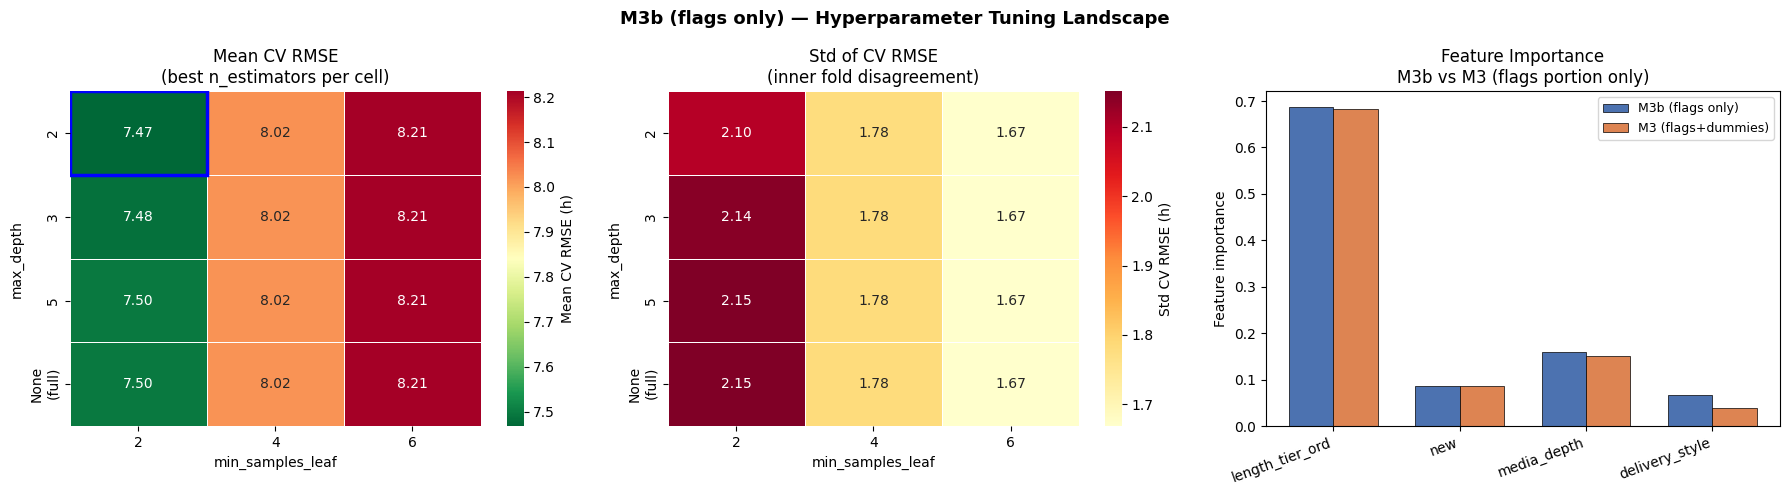

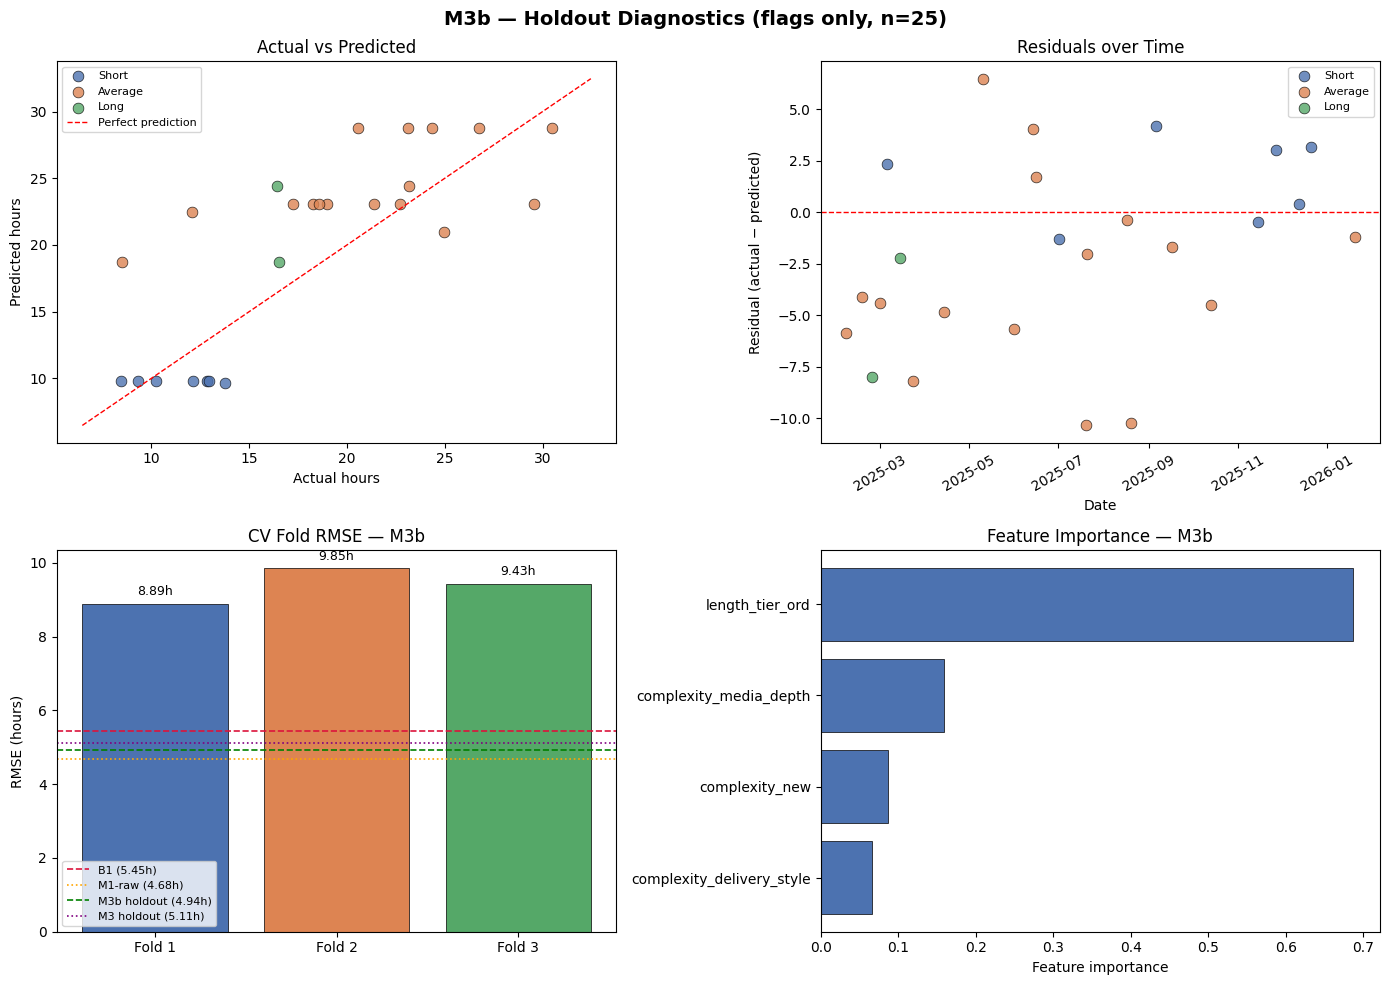


Residual summary (M3b holdout):
  Mean residual:    -2.02h
  Std of residuals: 4.51h

Mean residual by length tier:
  Short     n=7  mean residual=+1.61h
  Average   n=16  mean residual=-3.22h
  Long      n=2  mean residual=-5.13h


In [16]:
# ── M3b tuning landscape ──────────────────────────────────────────────────────
m3b_cv_df = pd.DataFrame(m3b_search.cv_results_)
m3b_cv_df['mean_rmse'] = -m3b_cv_df['mean_test_score']
m3b_cv_df['std_rmse']  =  m3b_cv_df['std_test_score']
m3b_cv_df['depth_label'] = m3b_cv_df['param_max_depth'].apply(
    lambda x: 'None\n(full)' if x is None else str(x)
)

m3b_best_per_cell = (
    m3b_cv_df.loc[
        m3b_cv_df.groupby(['depth_label', 'param_min_samples_leaf'])['mean_rmse'].idxmin()
    ]
    .set_index(['depth_label', 'param_min_samples_leaf'])
)
m3b_heat_mean = m3b_best_per_cell['mean_rmse'].unstack('param_min_samples_leaf').reindex(depth_order)
m3b_heat_std  = m3b_best_per_cell['std_rmse'].unstack('param_min_samples_leaf').reindex(depth_order)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('M3b (flags only) — Hyperparameter Tuning Landscape', fontsize=13, fontweight='bold')

# ── 1. Mean RMSE heatmap ──────────────────────────────────────────────────────
ax = axes[0]
sns.heatmap(m3b_heat_mean, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Mean CV RMSE (h)'})
ax.set_title('Mean CV RMSE\n(best n_estimators per cell)')
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('max_depth')
m3b_best_row  = m3b_cv_df.loc[m3b_cv_df['mean_rmse'].idxmin()]
m3b_best_depth = m3b_best_row['depth_label']
m3b_best_leaf  = m3b_best_row['param_min_samples_leaf']
if m3b_best_depth in depth_order and m3b_best_leaf in m3b_heat_mean.columns:
    ri = depth_order.index(m3b_best_depth)
    ci = list(m3b_heat_mean.columns).index(m3b_best_leaf)
    ax.add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False, edgecolor='blue', lw=2.5))

# ── 2. Std heatmap ────────────────────────────────────────────────────────────
ax = axes[1]
sns.heatmap(m3b_heat_std, ax=ax, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Std CV RMSE (h)'})
ax.set_title('Std of CV RMSE\n(inner fold disagreement)')
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('max_depth')

# ── 3. Feature importance vs M3 ───────────────────────────────────────────────
ax = axes[2]
m3b_imp_dict  = dict(zip(FLAGS_FEATURES, m3b_imps))
m3_imp_dict   = dict(zip(ALL_FEATURES, final_search.best_estimator_.feature_importances_))
x_pos = np.arange(len(FLAGS_FEATURES))
width = 0.35
bars_m3b = ax.bar(x_pos - width/2, [m3b_imp_dict[f] for f in FLAGS_FEATURES],
                  width, label='M3b (flags only)', color='#4C72B0', edgecolor='k', linewidth=0.5)
bars_m3  = ax.bar(x_pos + width/2, [m3_imp_dict.get(f, 0) for f in FLAGS_FEATURES],
                  width, label='M3 (flags+dummies)', color='#DD8452', edgecolor='k', linewidth=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels([f.replace('complexity_', '') for f in FLAGS_FEATURES], rotation=20, ha='right')
ax.set_ylabel('Feature importance')
ax.set_title('Feature Importance\nM3b vs M3 (flags portion only)')
ax.legend(fontsize=9)

fig_heatmap_m3b = fig
plt.tight_layout()
plt.show()

# ── M3b holdout diagnostic plots ──────────────────────────────────────────────
m3b_residuals = m3b_y_test - m3b_preds
m3b_tiers     = m3b_test['length_tier'].values
m3b_dates     = m3b_test['date_first'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('M3b — Holdout Diagnostics (flags only, n=25)', fontsize=14, fontweight='bold')

ax = axes[0, 0]
for tier in LENGTH_TIER_ORDER:
    mask = m3b_tiers == tier
    ax.scatter(m3b_y_test[mask], m3b_preds[mask], color=tier_colors[tier], label=tier,
               alpha=0.8, edgecolors='k', linewidths=0.5, s=60)
lim = [min(m3b_y_test.min(), m3b_preds.min()) - 2, max(m3b_y_test.max(), m3b_preds.max()) + 2]
ax.plot(lim, lim, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual hours'); ax.set_ylabel('Predicted hours')
ax.set_title('Actual vs Predicted'); ax.legend(fontsize=8)

ax = axes[0, 1]
for tier in LENGTH_TIER_ORDER:
    mask = m3b_tiers == tier
    ax.scatter(m3b_dates[mask], m3b_residuals[mask], color=tier_colors[tier], label=tier,
               alpha=0.8, edgecolors='k', linewidths=0.5, s=60)
ax.axhline(0, color='r', linestyle='--', linewidth=1)
ax.set_xlabel('Date'); ax.set_ylabel('Residual (actual − predicted)')
ax.set_title('Residuals over Time'); ax.tick_params(axis='x', rotation=30); ax.legend(fontsize=8)

ax = axes[1, 0]
m3b_fold_rmses = cv_results['M3b'][1]
bars = ax.bar([f'Fold {i+1}' for i in range(3)], m3b_fold_rmses,
              color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='k', linewidth=0.5)
ax.axhline(B1_RMSE,   color='crimson', linestyle='--', linewidth=1.2, label=f'B1 ({B1_RMSE}h)')
ax.axhline(M1R_RMSE,  color='orange',  linestyle=':',  linewidth=1.2, label=f'M1-raw ({M1R_RMSE}h)')
ax.axhline(m3b_rmse,  color='green',   linestyle='--', linewidth=1.2, label=f'M3b holdout ({m3b_rmse:.2f}h)')
ax.axhline(final_rmse, color='purple', linestyle=':',  linewidth=1.2, label=f'M3 holdout ({final_rmse:.2f}h)')
for bar, val in zip(bars, m3b_fold_rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{val:.2f}h', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('RMSE (hours)'); ax.set_title('CV Fold RMSE — M3b'); ax.legend(fontsize=8)

ax = axes[1, 1]
feat_imp_sorted = sorted(zip(FLAGS_FEATURES, m3b_imps), key=lambda x: x[1])
feats_s, imps_s = zip(*feat_imp_sorted)
ax.barh(feats_s, imps_s, color='#4C72B0', edgecolor='k', linewidth=0.5)
ax.set_xlabel('Feature importance'); ax.set_title('Feature Importance — M3b')

plt.tight_layout()
plt.show()

print(f"\nResidual summary (M3b holdout):")
print(f"  Mean residual:    {m3b_residuals.mean():+.2f}h")
print(f"  Std of residuals: {m3b_residuals.std():.2f}h")
print(f"\nMean residual by length tier:")
for tier in LENGTH_TIER_ORDER:
    mask = m3b_tiers == tier
    if mask.sum() > 0:
        print(f"  {tier:<8}  n={mask.sum()}  mean residual={m3b_residuals[mask].mean():+.2f}h")

In [17]:
# Log M3b holdout run to MLflow
with mlflow.start_run(run_name='holdout_M3b'):
    mlflow.log_param('model',        'M3b')
    mlflow.log_param('features',     FLAGS_FEATURES)
    mlflow.log_param('train_n',      len(m3b_X_train))
    mlflow.log_param('test_n',       len(m3b_X_test))
    mlflow.log_param('b1_rmse',      B1_RMSE)
    mlflow.log_param('m1_raw_rmse',  M1R_RMSE)
    mlflow.log_param('holdout_rmse', round(float(m3b_rmse), 4))
    mlflow.log_param('beats_b1',     int(m3b_rmse < B1_RMSE))
    for k, v in m3b_search.best_params_.items():
        mlflow.log_param(k, v)
    # beats_m1_raw as metric so retrain history shows whether the tree
    # ever crosses the Ridge threshold as training data grows.
    mlflow.log_metric('beats_m1_raw', int(m3b_rmse < M1R_RMSE))
    for feat, imp in zip(FLAGS_FEATURES, m3b_imps):
        mlflow.log_metric(f'importance_{feat}', round(float(imp), 4))
    mlflow.log_figure(fig_heatmap_m3b, 'tuning_heatmap.png')
    mlflow.sklearn.log_model(m3b_search.best_estimator_, artifact_path='model')

print(f'M3b holdout logged: RMSE={m3b_rmse:.2f}h')


2026/03/11 09:08:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/11 09:08:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


M3b holdout logged: RMSE=4.94h


In [18]:
# ── M3b Serialization ────────────────────────────────────────────────────────────────────────────
# M3b is not the production model but is serialized so monitor.py can track
# its residuals alongside M1-raw and flag if it ever outperforms post-retrain.
import json
import joblib

M3B_MODEL_NAME = 'yt_hours_rf_flags_v1'
ARTIFACTS_DIR  = Path('../artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)

m3b_model_path = ARTIFACTS_DIR / f'{M3B_MODEL_NAME}.pkl'
joblib.dump(m3b_search.best_estimator_, m3b_model_path)

m3b_meta = {
    'model_id':    M3B_MODEL_NAME,
    'model_class': 'RandomForestRegressor',
    'target':      'hours_creation',
    'features':    FLAGS_FEATURES,
    'best_params': {k: (None if v is None else v) for k, v in m3b_search.best_params_.items()},
    'holdout_rmse': round(float(m3b_rmse), 4),
    'b1_rmse':      B1_RMSE,
    'train_n':      int(len(m3b_X_train)),
    'test_n':       int(len(m3b_X_test)),
    'notes': (
        'Alternative to M1-raw. Random Forest on same flags+length features as Ridge. '
        'Holdout RMSE worse than M1-raw; rejected as production model. '
        'Serialized for monitoring comparison only. '
        'Feature set identical to M1-raw: length_tier_ord + 3 complexity flags.'
    ),
}

m3b_meta_path = ARTIFACTS_DIR / f'{M3B_MODEL_NAME}_meta.json'
with open(m3b_meta_path, 'w') as fh:
    json.dump(m3b_meta, fh, indent=2)

# Verify round-trip
m3b_loaded = joblib.load(m3b_model_path)
m3b_verify_rmse = rmse(m3b_y_test, m3b_loaded.predict(m3b_X_test))
assert abs(m3b_verify_rmse - m3b_rmse) < 1e-6, 'Round-trip RMSE mismatch'

print(f'Saved:  {m3b_model_path}')
print(f'Saved:  {m3b_meta_path}')
print(f'Round-trip RMSE check passed: {m3b_verify_rmse:.4f}h == {m3b_rmse:.4f}h')
print('Metadata preview:')
print(json.dumps(m3b_meta, indent=2))


Saved:  ..\artifacts\yt_hours_rf_flags_v1.pkl
Saved:  ..\artifacts\yt_hours_rf_flags_v1_meta.json
Round-trip RMSE check passed: 4.9378h == 4.9378h
Metadata preview:
{
  "model_id": "yt_hours_rf_flags_v1",
  "model_class": "RandomForestRegressor",
  "target": "hours_creation",
  "features": [
    "length_tier_ord",
    "complexity_new",
    "complexity_media_depth",
    "complexity_delivery_style"
  ],
  "best_params": {
    "max_depth": 2,
    "min_samples_leaf": 2,
    "n_estimators": 200
  },
  "holdout_rmse": 4.9378,
  "b1_rmse": 5.45,
  "train_n": 73,
  "test_n": 25,
  "notes": "Alternative to M1-raw. Random Forest on same flags+length features as Ridge. Holdout RMSE worse than M1-raw; rejected as production model. Serialized for monitoring comparison only. Feature set identical to M1-raw: length_tier_ord + 3 complexity flags."
}
